# L1 demo: an analysis that does not reproduce

This notebook loads a year of roadside air-quality sensor data, plots a reference
measurement against the corresponding sensor channel, fits a naive calibration, and
integrates the concentration curve to get a cumulative exposure.

All of that is ordinary work. The notebook is nonetheless broken in **three**
independent ways, and you will meet them in order as you run it from the top.

Your job is to name each one before I do, and to say not just what the fix is but
what practice would have stopped it reaching a colleague. None of the three are
exotic. That is the point: reproducibility fails for boring reasons, and boring
reasons are the ones that survive review.

> Data: [UCI Air Quality Data Set](https://archive.ics.uci.edu/dataset/360/air+quality),
> De Vito et al. Hourly readings from a multisensor device deployed on an Italian
> roadside, March 2004 onward.

## Run this first on Colab

Colab starts from its own preinstalled environment rather than this course's `uv`
environment, so run the cell below before anything else. It installs what this
notebook needs and Colab does not already have. Outside Colab it does nothing, so
you can run it or skip it.


In [1]:
# Run this first on Colab. Anywhere else this cell does nothing.
#
# Only genuinely missing packages are installed, so Colab's own versions of
# everything it already ships are left alone.
#
# Generated by tools/colab_setup.py from this notebook's imports. Edit that.
import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
}


def _missing(module):
    try:
        return importlib.util.find_spec(module) is None
    except ModuleNotFoundError:  # the parent package is absent
        return True


if "google.colab" in sys.modules:
    need = sorted({pip for mod, pip in REQUIREMENTS.items() if _missing(mod)})
    if need:
        print("installing:", " ".join(need))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)
    print("Colab setup done." if need else "Colab: nothing to install.")


## 1. Environment

These imports pull in NumPy, pandas, and scikit-learn, but nothing here records
*which version* of any of them this analysis was written against, and there is no
lockfile beside the notebook.

Print the versions and hold onto them. They matter in section 5.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sensorlab.dataprocess import clean, load
from sensorlab.train import train

print('numpy ', np.__version__)
print('pandas', pd.__version__)


numpy  2.5.2
pandas 2.3.3


## 2. Load the data

The raw CSV is **not in this repository**. Datasets do not belong in git: they bloat
the history, they are usually someone else's to license, and a repository is not a
distribution channel. So the next cell fetches it from UCI on first run and reuses the
local copy afterwards, which is what you should do in your own projects too.

The export has the usual instrument-file quirks, none of them announced: semicolon
separated, comma as the decimal mark, two trailing empty columns, and missing values
coded as `-200` rather than left blank.

In [3]:
from pathlib import Path

DATA_PATH = Path("../data/AirQualityUCI.csv")

print(f'using {DATA_PATH}')


using ..\data\AirQualityUCI.csv


### If that cell just failed

Read the error. It has nothing to do with statistics, sensors, or modelling. It is a
`FileNotFoundError`, and it happened while trying to *write* the downloaded file.

The download worked. The place it was told to put the file does not exist on your
machine, and never will.

**Problem one.** Fix it, rerun, and the fetch will succeed. Then keep going.

In [4]:
df = clean(load(DATA_PATH))

print(f'{len(df)} rows, {df.ts.min().date()} to {df.ts.max().date()}')
df.head(3)


9357 rows, 2004-03-10 to 2005-04-04


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,ts
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00


## 3. A first look

`CO(GT)` is a reference-grade carbon monoxide measurement. `PT08.S1(CO)` is the cheap
metal-oxide sensor that is supposed to track it. If the sensor is any good, these
should be related.

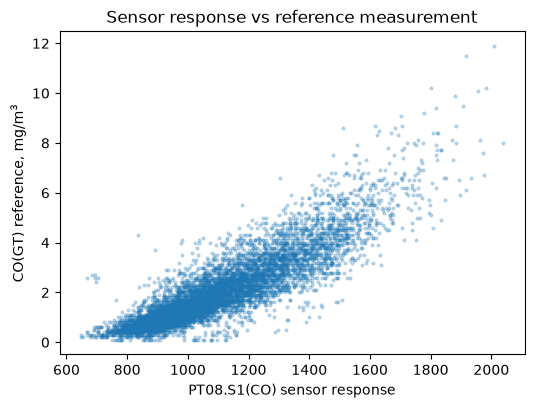

In [5]:
d = df.dropna(subset=['CO(GT)', 'PT08.S1(CO)'])

fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(d['PT08.S1(CO)'], d['CO(GT)'], s=4, alpha=0.25)
ax.set_xlabel('PT08.S1(CO) sensor response')
ax.set_ylabel('CO(GT) reference, mg/m$^3$')
ax.set_title('Sensor response vs reference measurement')
plt.show()

## 4. A naive calibration

Fit a linear model from the sensor channel to the reference, hold out a quarter of
the data, and score it.

In [6]:
seed = 0
model, score = train(DATA_PATH, seed)

print(f'R2 on held-out data: {score:.4f}')
print(f'slope {model.coef_[0]:.5f}, intercept {model.intercept_:.5f}')


R2 on held-out data: 0.7755
slope 0.00576, intercept -4.27356


### Run that cell again

Do not change anything. Run it a second time, and a third. Write the numbers down.

Then decide which of them you would be willing to put in a report, and how you would
answer a reviewer who asked you to reproduce it six months from now.

**Problem two.**

## 5. Cumulative exposure

A calibration is not the quantity a health question actually needs. What matters is
cumulative dose: the area under the concentration curve over the deployment. That is
a numerical integration over the hourly series.

We do it for two pollutants. **Run both cells.**

In [7]:
hourly_co = d.set_index('ts')['CO(GT)'].resample('h').mean().dropna()
hours_co = (hourly_co.index - hourly_co.index[0]).total_seconds() / 3600.0

exposure_co = np.trapezoid(hourly_co.values, hours_co)
print(f'Integrated CO exposure:  {exposure_co:,.0f} mg-h/m3')

Integrated CO exposure:  19,878 mg-h/m3


In [8]:
nox = df.dropna(subset=['NOx(GT)'])
hourly_nox = nox.set_index('ts')['NOx(GT)'].resample('h').mean().dropna()
hours_nox = (hourly_nox.index - hourly_nox.index[0]).total_seconds() / 3600.0

exposure_nox = np.trapezoid(hourly_nox.values, hours_nox)
print(f'Integrated NOx exposure: {exposure_nox:,.0f} ppb-h')

Integrated NOx exposure: 2,263,450 ppb-h


### Exactly one of those two cells failed

Not both, and not neither. Which one depends on the NumPy version you printed in
section 1.

**Compare with the person next to you.** If you got different failures, neither of
you did anything wrong, and that is the entire lesson. Both cells are ordinary
numerical integration. Both were correct when someone wrote them.

**Problem three.** Note that nothing in this repository told you which version this
analysis expected, so nothing told you which cell was the broken one.

---

## Your turn

Fill this in. The last column is the one that matters.



| # | Symptom | Root cause | Fix | Practice that prevents it |
|---|---|---|---|---|
| 1 | FileNotFoundError: [Errno 2] No such file or directory: '\Users\jkitchin\Dropbox\classes\f26-systems-toolchains\data\AirQualityUCI.csv'| The notebook hard-codes an absolute path|Replace the absolute path with the project-relative path |Show the expected folder structure in the README and always use relative paths within the project |
| 2 | R2 on held-out data from different experiments are different| train_test_split uses randomness, but random_state was not supplied|Define a seed and fix it as random_state=seed |Always set and record the random seed |
| 3 | AttributeError: module 'numpy' has no attribute 'trapz'| API availability may change in different package versions and will cause failure| Change np.trapz to np.trapezoid| Always check that each API is available in the applied library version, and use uv to manage the environment and save the exact dependency versions in uv.lock.|

Two questions to take away:

- Problem two does not raise an error. Nothing in the output marks it as wrong. How
  many analyses have you run that had this property?
- Problem three was introduced by a library doing something entirely reasonable, a
  deprecated name being removed in a major release. Whose responsibility was it to
  notice?

We rebuild this properly in **L2**: a `uv`-managed project with a locked environment,
a pinned interpreter, relative paths, seeded splits, and the analysis moved out of the
notebook into a module you can test and rerun. That is also assignment **A1**.